## os and system path

In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

## Import libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

c:\Users\palla\OneDrive\Desktop\nita-sem-3\ak-pu\ts\smart-forecast-studio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load dataset

In [6]:
# Load dataset
df = pd.read_csv("../data/AirPassengers.csv")

# Display first 5 rows
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## Check Dataset

In [7]:
df.info()

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.4 KB


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## Rename Columns for Prophet

In [8]:
df = df.rename(columns={
    "Month": "ds",
    "Passengers": "y"
})

## Convert Date Column

In [9]:
df["ds"] = pd.to_datetime(df["ds"])
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


## Create Prophet Model

In [10]:
model = Prophet()

## Fit Model

In [11]:
model.fit(df)

10:45:21 - cmdstanpy - INFO - Chain [1] start processing
10:45:21 - cmdstanpy - INFO - Chain [1] done processing


## Create Future Dates

In [12]:
future = model.make_future_dataframe(
    periods=30,
    freq="MS"
)
future.tail()

,ds
169,1963-02-01
170,1963-03-01
171,1963-04-01
172,1963-05-01
173,1963-06-01


## Generate the forecast

In [13]:
forecast = model.predict(future)

## View Forecast

In [14]:
forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].tail()

,ds,yhat,yhat_lower,yhat_upper
169,1963-02-01,530.965754,502.115850,559.407822
170,1963-03-01,569.100678,540.795767,598.847523
171,1963-04-01,563.215078,532.984999,591.834653
172,1963-05-01,570.720170,540.891819,599.543294
173,1963-06-01,608.995652,581.540943,637.230970


## Plot Forecast

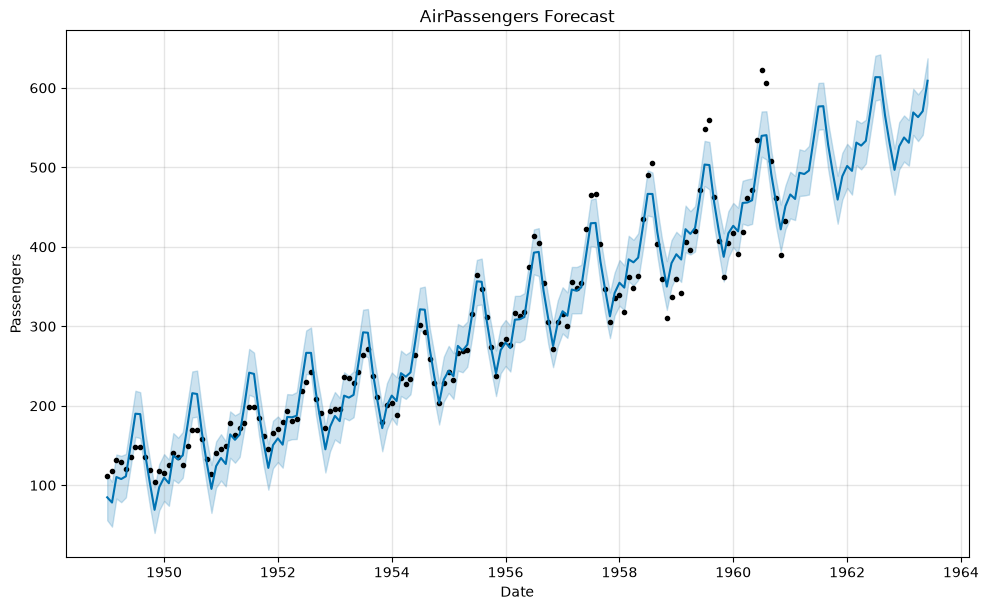

In [15]:
fig = model.plot(forecast)

plt.title("AirPassengers Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.show()

## Plot Trend & Seasonality

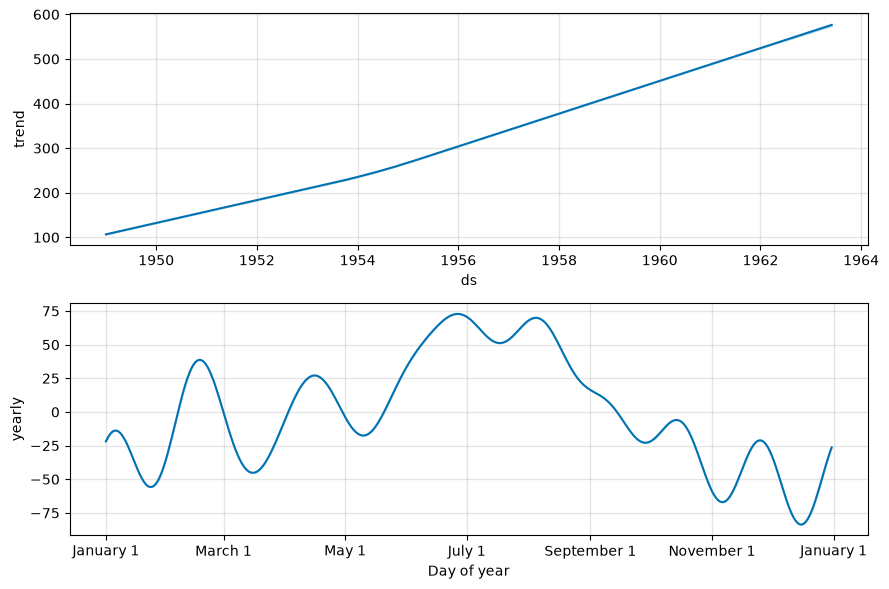

In [16]:
fig2 = model.plot_components(forecast)

plt.show()

## Compare Actual vs Forecast

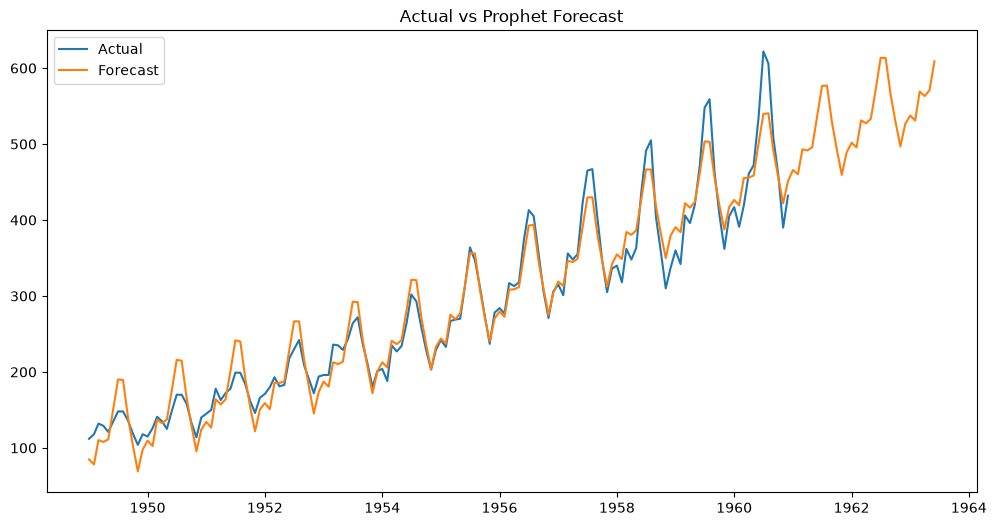

In [17]:
plt.figure(figsize=(12,6))

plt.plot(df["ds"], df["y"], label="Actual")

plt.plot(
    forecast["ds"],
    forecast["yhat"],
    label="Forecast"
)

plt.legend()

plt.title("Actual vs Prophet Forecast")

plt.show()

## Save Forecast

In [18]:
forecast.to_csv("../outputs/air_passenger_forecast.csv", index=False)

print("Forecast saved successfully!")

Forecast saved successfully!


## Data_loader testing

In [19]:


from src.data_loader import load_data

try:
    df = load_data("../data/AirPassengers.csv")

    print("Dataset Loaded Successfully")
    print(df.head())

except Exception as e:
    print(e)

Dataset Loaded Successfully
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


## preprocess testing

In [20]:
from src.data_loader import load_data
from src.preprocess import preprocess_data

# Load dataset
df = load_data("../data/AirPassengers.csv")

# Preprocess
df = preprocess_data(df)

print(df.head())

          ds    y
0 1949-01-01  112
1 1949-02-01  118
2 1949-03-01  132
3 1949-04-01  129
4 1949-05-01  121


## prophet model usage

In [ ]:
from src.data_loader import load_data
from src.preprocess import preprocess_data
from src.prophet_model import (
    create_model,
    train_model,
    generate_forecast
)

# Load data
df = load_data("../data/AirPassengers.csv")

# Preprocess
df = preprocess_data(df)

# Create model
model = create_model()

# Train
model = train_model(model, df)

# Forecast next 30 months
forecast = generate_forecast(
    model,
    periods=30,
    freq="MS"
)

print(forecast.head())

## evaluation usage

In [ ]:
from src.data_loader import load_data
from src.preprocess import preprocess_data
from src.prophet_model import (
    create_model,
    train_model,
    generate_forecast
)
from src.evaluation import evaluate_model

# Load data
df = load_data("../data/AirPassengers.csv")

# Preprocess
df = preprocess_data(df)

# Train model
model = create_model()
model = train_model(model, df)

# Generate forecast
forecast = generate_forecast(model)

# Compare only historical predictions
historical = forecast.iloc[:len(df)]

metrics = evaluate_model(
    actual=df["y"],
    predicted=historical["yhat"]
)

print(metrics)

10:14:15 - cmdstanpy - INFO - Chain [1] start processing
10:14:15 - cmdstanpy - INFO - Chain [1] done processing


{'MAE': 17.382370635083014, 'RMSE': np.float64(22.477889745743614), 'MAPE': np.float64(7.266845795217101)}


## visualization usage

10:14:19 - cmdstanpy - INFO - Chain [1] start processing
10:14:19 - cmdstanpy - INFO - Chain [1] done processing


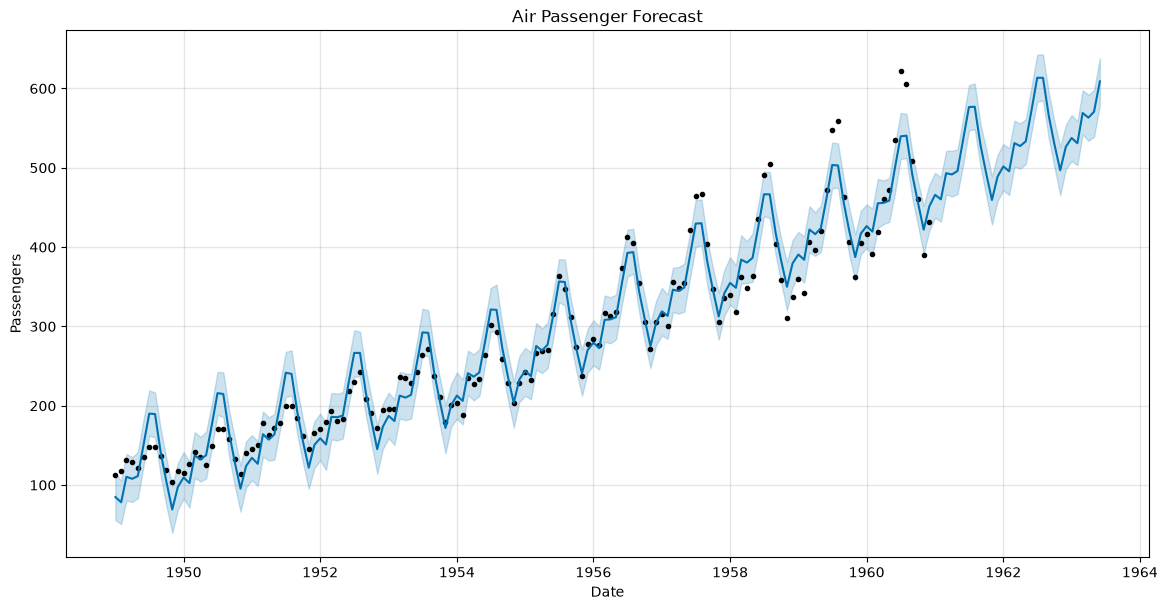

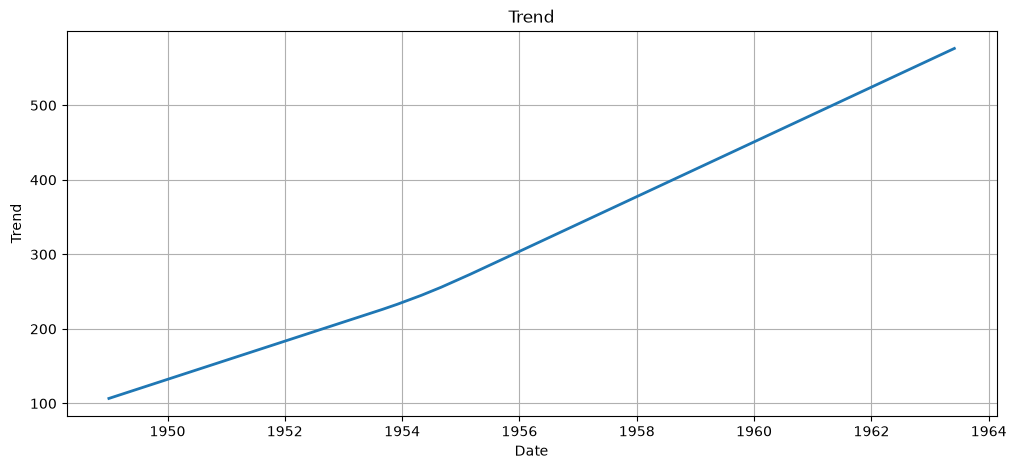

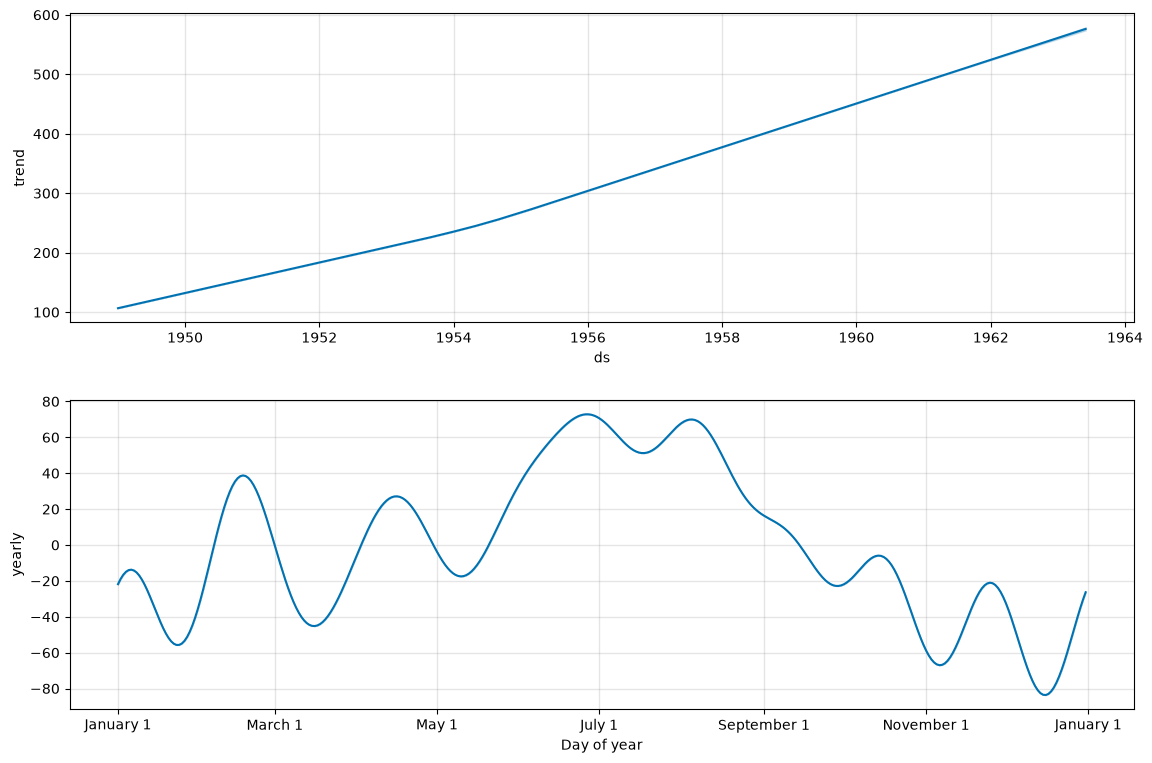

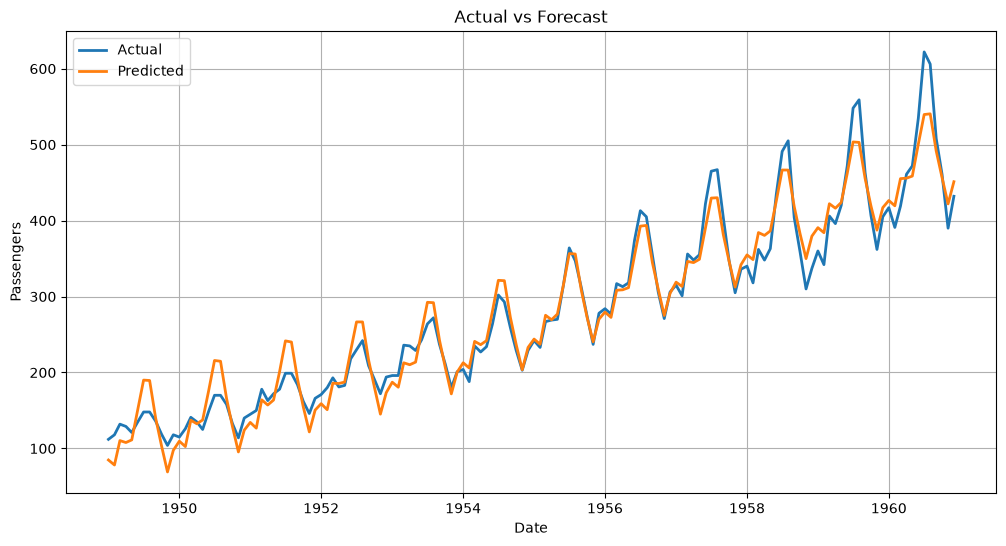

In [ ]:
from src.data_loader import load_data
from src.preprocess import preprocess_data
from src.prophet_model import (
    create_model,
    train_model,
    generate_forecast
)
from src.visualization import (
    plot_forecast,
    plot_trend,
    plot_seasonality,
    plot_actual_vs_forecast
)

# Load data
df = load_data("../data/AirPassengers.csv")

# Preprocess
df = preprocess_data(df)

# Train model
model = create_model()
model = train_model(model, df)

# Forecast
forecast = generate_forecast(model)

# Forecast plot
plot_forecast(model, forecast)

# Trend plot
plot_trend(forecast)

# Seasonality plot
plot_seasonality(model, forecast)

# Actual vs Forecast
plot_actual_vs_forecast(df, forecast)

## updated preprocess


In [ ]:
import importlib
import src.preprocess
importlib.reload(src.preprocess)

from src.preprocess import preprocess_data, handle_missing_values

In [ ]:
df = handle_missing_values(df)

## utils library

In [ ]:
from src.utils import detect_frequency

In [ ]:
print(df.columns)

Index(['Month', 'Passengers'], dtype='str')


In [ ]:
from src.data_loader import load_data
from src.preprocess import preprocess_data
from src.utils import detect_frequency

df = load_data("../data/AirPassengers.csv")
#df = df.rename(columns={"#Passengers": "Passengers"})
df = preprocess_data(df)      # renames Month/Passengers -> ds/y
print(df.columns)             # sanity check: should show ['ds', 'y']

freq = detect_frequency(df)   # works now that df has 'ds'

forecast_periods = 24
future = model.make_future_dataframe(
    periods=forecast_periods,
    freq=freq
)

Index(['ds', 'y'], dtype='str')


NameError: name 'model' is not defined

## updated prophet_model.py

In [ ]:
# Default: yearly seasonality only, no holidays
model = create_model()

# With Indian holidays
model = create_model(country="IN")

# Custom seasonality + holidays
model = create_model(weekly_seasonality=True, country="US")